In [1]:
import numpy as np
import pandas as pd
import csv
import random
from sklearn.linear_model import LogisticRegression
import sys
import os

sys.path.insert(0, "../../../Modules")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)
random.seed(0)
np.random.seed(0)

from utils import *

enc = 'utf-8'

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
NUTS0 = 'IT'
NUTS2 = 'Veneto'

In [4]:
YEAR = 2023


In [5]:
#class ratio must be [0,1]
#lower number means more aggressive spliting towards the higher classes

NUMBER_OF_CLASSES = 10
CLASS_RATIO = 0.55

In [6]:
base_path = f'../../data/{NUTS2}/results/'

In [7]:
file_list = os.listdir(base_path)
file_list.sort()
file_list

['IT_Veneto_Results_2008-2019.csv',
 'IT_Veneto_Results_2023-July-1st.csv',
 'IT_Veneto_Results_2023-July-2nd.csv',
 'IT_Veneto_Results_2023-June-1st.csv',
 'IT_Veneto_Results_2023-June-2nd.csv',
 'IT_Veneto_Results_2023-May-1st.csv',
 'IT_Veneto_Results_2023-May-2nd.csv']

In [8]:
file = file_list[0]

data = pd.read_csv(f'{base_path}/{file}', encoding='utf-8')
data.drop(columns=['x', 'y'], inplace=True)
data.rename(columns={"probability": "score", "municipality": "lau1"}, inplace=True)

In [9]:
data

,lau1,day,month,year,case,score
0,jesolo,16,8,2018,0,9.989788e-01
1,ceggia,16,8,2018,0,9.982185e-01
2,motta da livenza,16,8,2018,0,9.980037e-01
3,noventa da piave,16,8,2018,0,9.979486e-01
4,caorle,16,8,2018,0,9.974389e-01
...,...,...,...,...,...,...
82219,rocca pietore,1,6,2008,0,4.362943e-12
82220,rocca pietore,1,6,2010,0,3.531329e-12
82221,cortina da ampezzo,1,6,2010,0,3.349093e-12
82222,falcade,1,6,2010,0,2.646350e-12


In [10]:
data_og = data.copy()

In [11]:
np.sort(data.month.unique())

array([ 6,  7,  8,  9, 10, 11], dtype=int64)

In [12]:
np.sort(data.year.unique())

array([2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018,
       2019], dtype=int64)

In [13]:
zero_score = {'lau1': 'nan', 'day': 0, 'month': 0, 'year': 0, 'case': 0, 'score': 0}
one_score = {'lau1': 'nan', 'day': 0, 'month': 0, 'year': 0, 'case': 0, 'score': 1}

In [14]:
data = data.append(zero_score, ignore_index = True)
data = data.append(one_score, ignore_index = True)

In [15]:
data

,lau1,day,month,year,case,score
0,jesolo,16,8,2018,0,9.989788e-01
1,ceggia,16,8,2018,0,9.982185e-01
2,motta da livenza,16,8,2018,0,9.980037e-01
3,noventa da piave,16,8,2018,0,9.979486e-01
4,caorle,16,8,2018,0,9.974389e-01
...,...,...,...,...,...,...
82221,cortina da ampezzo,1,6,2010,0,3.349093e-12
82222,falcade,1,6,2010,0,2.646350e-12
82223,lamon,16,11,2019,0,2.331512e-12
82224,nan,0,0,0,0,0.000000e+00


In [16]:
data_sorted = data.sort_values(by='score', ascending=True)
data_sorted.reset_index(drop = True, inplace = True)
data_sorted

,lau1,day,month,year,case,score
0,nan,0,0,0,0,0.000000e+00
1,lamon,16,11,2019,0,2.331512e-12
2,falcade,1,6,2010,0,2.646350e-12
3,cortina da ampezzo,1,6,2010,0,3.349093e-12
4,rocca pietore,1,6,2010,0,3.531329e-12
...,...,...,...,...,...,...
82221,noventa da piave,16,8,2018,0,9.979486e-01
82222,motta da livenza,16,8,2018,0,9.980037e-01
82223,ceggia,16,8,2018,0,9.982185e-01
82224,jesolo,16,8,2018,0,9.989788e-01


<AxesSubplot:>

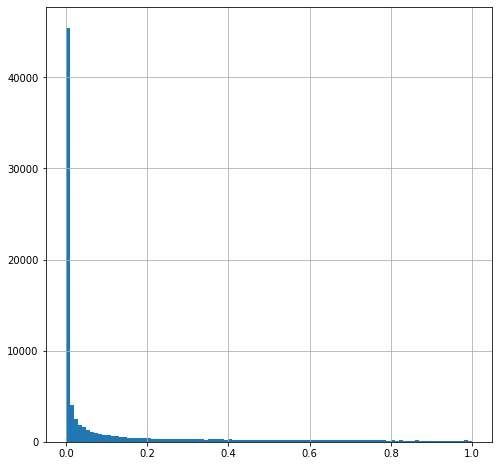

In [17]:
data_og.score.hist(bins = 100, figsize = (8,8))

In [18]:
number_of_observations = len(data_sorted)

In [19]:
r_sum = 0

for i in range(NUMBER_OF_CLASSES):
    r_sum = r_sum + CLASS_RATIO**i

x = round(number_of_observations/r_sum)

x

37096

In [20]:
temp_x = x
total_obs = 0
obs = []

for c in range(NUMBER_OF_CLASSES):
    total_obs = total_obs + temp_x
    obs.append(temp_x)
    print(f'Class {c}: {temp_x} observations')
    temp_x = round(temp_x*CLASS_RATIO)
    
print(f'\nTotal Observations: {total_obs}')

Class 0: 37096 observations
Class 1: 20403 observations
Class 2: 11222 observations
Class 3: 6172 observations
Class 4: 3395 observations
Class 5: 1867 observations
Class 6: 1027 observations
Class 7: 565 observations
Class 8: 311 observations
Class 9: 171 observations

Total Observations: 82229


In [21]:
bins = []
sum = 0
for index in obs:
    sum = sum + index
    try:
        bin_lim = data_sorted.loc[sum, 'score']
    except KeyError:
        bin_lim = data_sorted.loc[number_of_observations-1, 'score']
    bins.append(bin_lim)

bins.insert(0,0)
bins[-1] = 1 

In [22]:
data_og['risk_class'] = pd.cut(data_og['score'], bins=bins, labels=False, include_lowest=True)

data_og.risk_class.value_counts().sort_index()

0    37096
1    20403
2    11222
3     6172
4     3395
5     1867
6     1027
7      565
8      311
9      166
Name: risk_class, dtype: int64

In [23]:
bins_formatted = [ '%.4f' % elem for elem in bins]
print(bins_formatted)

['0.0000', '0.0024', '0.0662', '0.2917', '0.5406', '0.7128', '0.8345', '0.9141', '0.9596', '0.9832', '1.0000']


In [24]:
class9 = data_og.loc[data_og.risk_class == 9]
class8 = data_og.loc[data_og.risk_class == 8]
class7 = data_og.loc[data_og.risk_class == 7]
class6 = data_og.loc[data_og.risk_class == 6]
class5 = data_og.loc[data_og.risk_class == 5]
class4 = data_og.loc[data_og.risk_class == 4]
class3 = data_og.loc[data_og.risk_class == 3]
class2 = data_og.loc[data_og.risk_class == 2]
class1 = data_og.loc[data_og.risk_class == 1]
class0 = data_og.loc[data_og.risk_class == 0]

In [25]:
means = []

means.append(class0.case.mean())
means.append(class1.case.mean())
means.append(class2.case.mean())
means.append(class3.case.mean())
means.append(class4.case.mean())
means.append(class5.case.mean())
means.append(class6.case.mean())
means.append(class7.case.mean())
means.append(class8.case.mean())
means.append(class9.case.mean())

means

[8.087125296527928e-05,
 0.0004901240013723472,
 0.0028515416146854392,
 0.008749189889825017,
 0.009720176730486009,
 0.012854847348687734,
 0.03018500486854917,
 0.03716814159292035,
 0.06430868167202572,
 0.12048192771084337]

In [26]:
class_bins = []

In [27]:
class_very_low = pd.concat([class0, class1, class2])
class_very_low.reset_index(drop = True, inplace = True)
class_very_low

print(f'Threashold: ({class_very_low.score.min():.3f} - {class_very_low.score.max():.3f})')
print(f'Samples: {len(class_very_low)}')
print(f'% Samples: {len(class_very_low)/len(data_og) * 100:.3f} %')
print(f'Accuracy: {class_very_low.case.mean() * 100 :.2f} %')

class_bins.append(0)

Threashold: (0.000 - 0.292)
Samples: 68721
% Samples: 83.578 %
Accuracy: 0.07 %


In [28]:
class_low = pd.concat([class3, class4])
class_low.reset_index(drop = True, inplace = True)
class_low

print(f'Threashold: ({class_low.score.min():.3f} - {class_low.score.max():.3f})')
print(f'Samples: {len(class_low)}')
print(f'% Samples: {len(class_low)/len(data_og) * 100:.3f} %')
print(f'Accuracy: {class_low.case.mean() * 100 :.2f} %')

class_bins.append(class_low.score.min())

Threashold: (0.292 - 0.713)
Samples: 9567
% Samples: 11.635 %
Accuracy: 0.91 %


In [29]:
class_mid = class5
class_mid.reset_index(drop = True, inplace = True)
class_mid

print(f'Threashold: ({class_mid.score.min():.3f} - {class_mid.score.max():.3f})')
print(f'Samples: {len(class_mid)}')
print(f'% Samples: {len(class_mid)/len(data_og) * 100:.3f} %')
print(f'Accuracy: {class_mid.case.mean() * 100 :.2f} %')

class_bins.append(class_mid.score.min())

Threashold: (0.713 - 0.835)
Samples: 1867
% Samples: 2.271 %
Accuracy: 1.29 %


In [30]:
class_mid_high = pd.concat([class6, class7])
class_mid_high.reset_index(drop = True, inplace = True)
class_mid_high

print(f'Threashold: ({class_mid_high.score.min():.3f} - {class_mid_high.score.max():.3f})')
print(f'Samples: {len(class_mid_high)}')
print(f'% Samples: {len(class_mid_high)/len(data_og) * 100:.3f} %')
print(f'Accuracy: {class_mid_high.case.mean() * 100 :.2f} %')

class_bins.append(class_mid_high.score.min())

Threashold: (0.835 - 0.960)
Samples: 1592
% Samples: 1.936 %
Accuracy: 3.27 %


In [31]:
class_high = class8
class_high.reset_index(drop = True, inplace = True)
class_high

print(f'Threashold: ({class_high.score.min():.3f} - {class_high.score.max():.3f})')
print(f'Samples: {len(class_high)}')
print(f'% Samples: {len(class_high)/len(data_og) * 100:.3f} %')
print(f'Accuracy: {class_high.case.mean() * 100 :.2f} %')

class_bins.append(class_high.score.min())

Threashold: (0.960 - 0.983)
Samples: 311
% Samples: 0.378 %
Accuracy: 6.43 %


In [32]:
class_very_high = class9
class_very_high.reset_index(drop = True, inplace = True)
class_very_high

print(f'Threashold: ({class_very_high.score.min():.3f} - {class_very_high.score.max():.3f})')
print(f'Samples: {len(class_very_high)}')
print(f'% Samples: {len(class_very_high)/len(data_og) * 100:.3f} %')
print(f'Accuracy: {class_very_high.case.mean() * 100 :.2f} %')

class_bins.append(class_very_high.score.min())

Threashold: (0.983 - 0.999)
Samples: 166
% Samples: 0.202 %
Accuracy: 12.05 %


In [33]:
class_bins.append(1)

In [34]:
class_bins_formatted = [ '%.4f' % elem for elem in class_bins]
print(class_bins_formatted)

['0.0000', '0.2917', '0.7128', '0.8345', '0.9597', '0.9832', '1.0000']


In [35]:
bins_path = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Bins_{YEAR}.csv'

with open(bins_path, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(class_bins)